[[14  1]
 [ 0 15]]


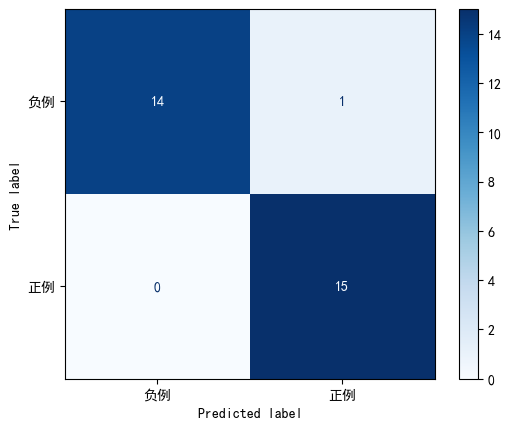

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "SimHei"
plt.rcParams["axes.unicode_minus"] = False

X, y = load_iris(return_X_y=True)
X = X[y != 0, 2:]
y = y[y != 0]
y[y == 1] = 0
y[y == 2] = 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(matrix)

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test, cmap=plt.cm.Blues,
                                     display_labels=["负例", "正例"])

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("正确率：", accuracy_score(y_test, y_pred))
print("精准率：", precision_score(y_test, y_pred))
print("召回率：", recall_score(y_test, y_pred))
print("F1值：", f1_score(y_test, y_pred))

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

正确率： 0.9666666666666667
精准率： 0.9375
召回率： 1.0
F1值： 0.967741935483871
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.94      1.00      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [3]:
import numpy as np

class OVRLogisticRegression:
    def __init__(self):
        # 假设已经训练好
        self.coef_ = None        # shape: (K, d)
        self.intercept_ = None   # shape: (K,)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def decision_function(self, X):
        """
        Z = X @ W^T + b
        """
        return X @ self.coef_.T + self.intercept_

    def predict_proba(self, X):
        """
        sklearn OvR 的核心逻辑
        """
        # 1. 线性输出
        Z = self.decision_function(X)

        # 2. 每一类独立 sigmoid
        P_raw = self.sigmoid(Z)

        # 3. 归一化（sklearn 的工程选择）
        P = P_raw / P_raw.sum(axis=1, keepdims=True)

        return P


In [4]:
import numpy as np

class MultinomialLogisticRegression:
    def __init__(self):
        self.coef_ = None        # shape: (K, d)
        self.intercept_ = None   # shape: (K,)

    def decision_function(self, X):
        return X @ self.coef_.T + self.intercept_

    def softmax(self, Z):
        """
        数值稳定版 softmax
        """
        Z = Z - Z.max(axis=1, keepdims=True)
        exp_Z = np.exp(Z)
        return exp_Z / exp_Z.sum(axis=1, keepdims=True)

    def predict_proba(self, X):
        Z = self.decision_function(X)
        P = self.softmax(Z)
        return P


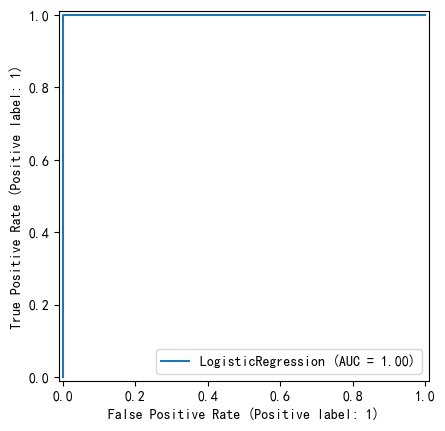

In [8]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(lr,X_test,y_test)

C:\Users\123\AppData\Local\Temp\ipykernel_5144\1549984390.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:,0],X[:,1],c='y',cmap=plt.cm.coolwarm)


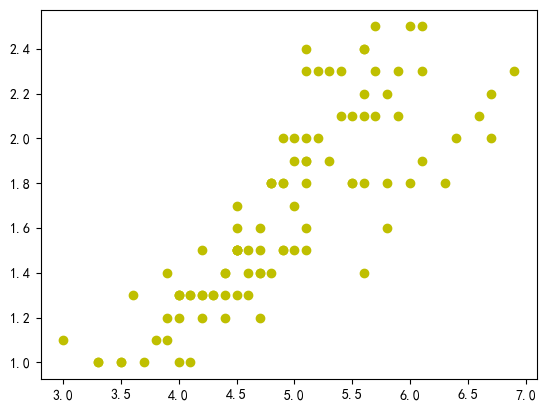

In [ ]:
from sklearn.datasets import make_classification
#n_classes:类别的数量
#n_clusters_per_class:每类簇的数量
#class_sep:不同类别的距离
#flip_y:随机设置样本类别的比例
make_classification(n_samples=200,n_features=2,n_redundant=0,
                    n_clusters_per_class=1,class_sep=2
                    flip_y=0)
plt.scatter(X[:,0],X[:,1],c='y',cmap=plt.cm.coolwarm)

              precision    recall  f1-score   support

           0       0.86      0.87      0.86       130
           1       0.90      0.89      0.89       170

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300



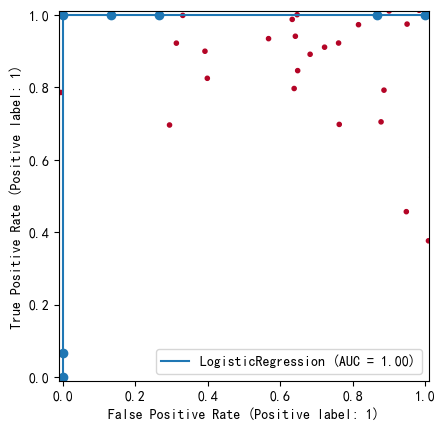

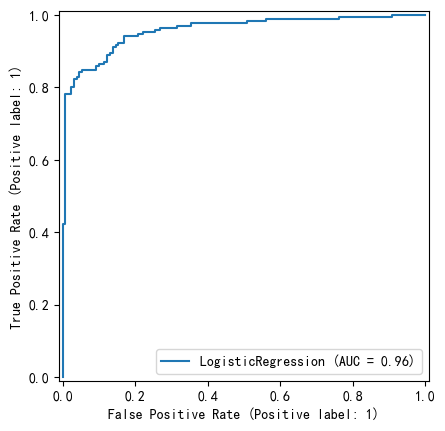

In [12]:
from sklearn.metrics import RocCurveDisplay

display = RocCurveDisplay.from_estimator(lr, X_test, y_test)
display.line_.set_marker("o")

from sklearn.datasets import make_classification

# n_classes：类别的数量。
# n_clusters_per_class：每个类别簇的数量。
# class_sep：不同类别之间的距离。
# flip_y：随机设置样本类别的比例。
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_classes=2, n_clusters_per_class=2,
                          class_sep=1.0, flip_y=0.01)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, marker=".")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=23)
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))
display = RocCurveDisplay.from_estimator(lr, X_test, y_test)
# display.line_.set_marker("o")

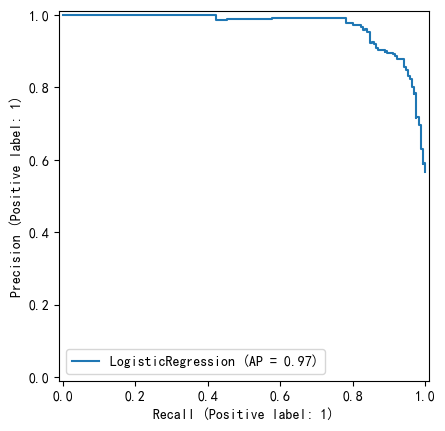

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
#阈值上升,精准率会上升,召回率会下降
PrecisionRecallDisplay.from_estimator(lr,X_test,y_test)

